<a href="https://colab.research.google.com/github/ZainabIftikhar1204/DL_Assg3/blob/main/DL_Assg3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.backends.cudnn as cudnn
from torch.utils.data import random_split
import torchvision.models as models


# Task 1: Custom CNNs and Shortcut Learning

## Part A: Standard MNIST

In [33]:
#Checks if GPU is available or not
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


In [ ]:
BATCH_SIZE = 16
EPOCHS = 25

### Setting up data

In [ ]:
# setting up transform for data normalization
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5), (0.5))
    ]
)

# loading dataset
total_train_dataset = torchvision.datasets.MNIST(root="data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="data", train=False, transform=transform, download=True)

# splitting training data into train and validation
train_size = int(0.8 * len(total_train_dataset))
val_size = len(total_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    total_train_dataset,
    [train_size, val_size]
)

# setting up loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)} Test: {len(test_dataset)}")

Train: 48000, Val: 12000 Test: 10000


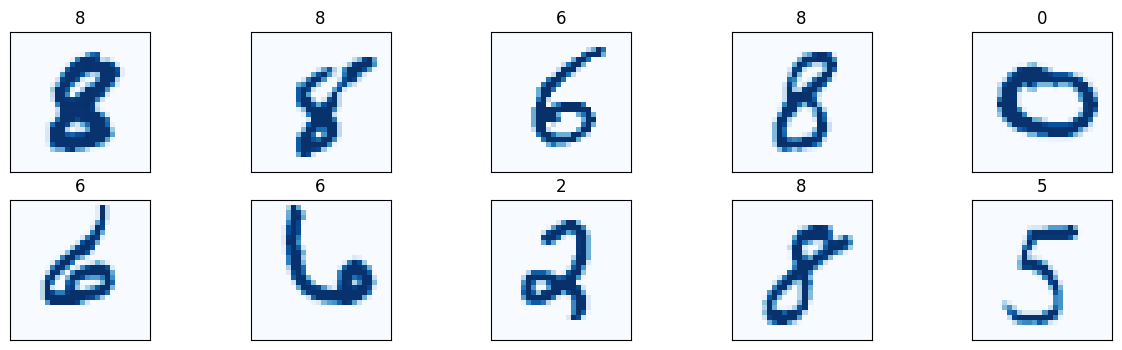

In [ ]:
# visualizing data
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

fig = plt.figure(figsize=(15, 4))
for idx in np.arange(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='Blues')
    ax.set_title(str(labels[idx].item()))

### Defining Model

In [ ]:
from torch.nn.modules.flatten import Flatten
from torch.nn.modules.activation import ReLU
class Custom_CNN(nn.Module):
  def __init__(self, in_dim):
     super().__init__()

     self.net = nn.Sequential(
         #C1
         nn.Conv2d(in_dim, 32, 3),
         nn.ReLU(),
         nn.MaxPool2d(2),

         #C2
         nn.Conv2d(32, 16, 3),
         nn.ReLU(),
         nn.MaxPool2d(2),

         #C3
        #  nn.Conv2d(32, 64, 3),
        #  nn.ReLU(),
        #  nn.MaxPool2d(2),

         #F4
         nn.Flatten(),
         nn.Linear(16 * 5 * 5, 64),
         nn.ReLU(),

         #Output Layer
         nn.Linear(64, 10)
     )

  def forward(self, x):
    return self.net(x)

In [ ]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
custom_cnn = Custom_CNN(1).to(device)

print(f"Number of Parameters: {count_trainable_parameters(custom_cnn)}")

Number of Parameters: 31258


In [ ]:
print(custom_cnn)

Custom_CNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=400, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=10, bias=True)
  )
)


### Utility Functions

In [17]:
def train_model(model, criterion, optimizer, train_loss_curve, val_loss_curve):

  for epoch in range(1, EPOCHS+1):
    print(f"Epoch {epoch}")
    train_loss = 0
    val_loss = 0

    # TRAINING
    model.train()

    for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)

      # clear prev grads
      optimizer.zero_grad()

      # forward pass
      outputs = model(images)
      loss = criterion(outputs, labels)

      # backward pass
      loss.backward()

      # update weights
      optimizer.step()
      train_loss += loss.item() * images.size(0)

    # avg train loss
    epoch_train_loss = train_loss/len(train_loader)

    # for plotting loss
    train_loss_curve.append(epoch_train_loss)

    # VALIDATION
    with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)

          outputs = model(images)
          loss = criterion(outputs, labels)

          val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_loss_curve.append(epoch_val_loss)

    print(f"Train Loss: {epoch_train_loss}, Val Loss: {epoch_val_loss}\n")



In [18]:
def evaluate_model(model):
  model.eval()

  correct_pred = 0
  total = 0

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)

      _, pred = torch.max(outputs, 1)
      total += labels.size(0)
      correct_pred += (pred == labels).sum().item()


  print(f"Accuracy: {100 * correct_pred / total}")


### Model training & Results

In [ ]:
# hyperparameters
l_r = 0.001
optimizer = optim.Adam(custom_cnn.parameters(), lr=l_r)
criterion = nn.CrossEntropyLoss()

cudnn.benchmark = True #to treat it as benchmark testing for speeding up process

In [ ]:
train_loss_curve = []
val_loss_curve = []
train_model(custom_cnn, criterion, optimizer, train_loss_curve, val_loss_curve)

Epoch 1
Train Loss: 2.5069644726182645, Val Loss: 0.0654789412424046

Epoch 2
Train Loss: 0.9112950901761651, Val Loss: 0.07512634623465904

Epoch 3
Train Loss: 0.6317590146408183, Val Loss: 0.055261154677078594

Epoch 4
Train Loss: 0.47199635831866665, Val Loss: 0.0684209802794309

Epoch 5
Train Loss: 0.37592095124935865, Val Loss: 0.05419577340621011

Epoch 6
Train Loss: 0.3007436658746913, Val Loss: 0.0577126541415461

Epoch 7
Train Loss: 0.2618448386290302, Val Loss: 0.0626791007436279

Epoch 8
Train Loss: 0.22705297872556204, Val Loss: 0.06243540265927771

Epoch 9
Train Loss: 0.2032309440360956, Val Loss: 0.07075540908296633

Epoch 10
Train Loss: 0.19697958421970096, Val Loss: 0.06462064756511227

Epoch 11
Train Loss: 0.16652239010782507, Val Loss: 0.0700165991930368

Epoch 12
Train Loss: 0.15216757849922405, Val Loss: 0.06405022735151135

Epoch 13
Train Loss: 0.1353213199115675, Val Loss: 0.0716441157944418

Epoch 14
Train Loss: 0.13342479912083893, Val Loss: 0.07377445684198101


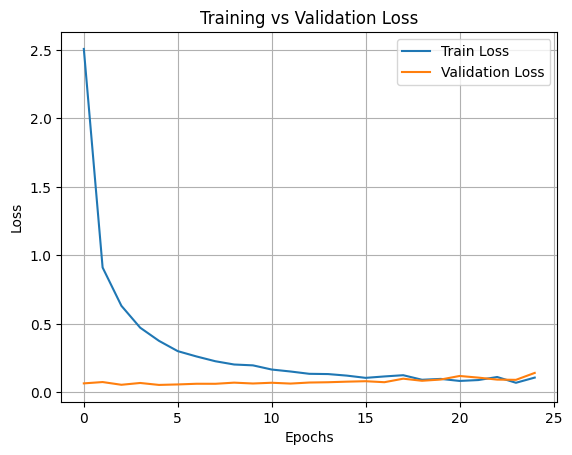

In [ ]:
plt.plot(train_loss_curve, label='Train Loss')
plt.plot(val_loss_curve, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()

plt.show()

### Model Evaluation & Results

In [ ]:
# custom_cnn.load_state_dict(torch.load("/content/custom_cnn_weights.pth"))

<All keys matched successfully>

In [ ]:
evaluate_model(custom_cnn)

Accuracy: 98.75


### Saving Model

In [ ]:
torch.save(custom_cnn.state_dict(), 'custom_cnn_weights.pth')

### Visualizing first conv layer weights


In [ ]:
# getting weights
weights = custom_cnn.net[0].weight

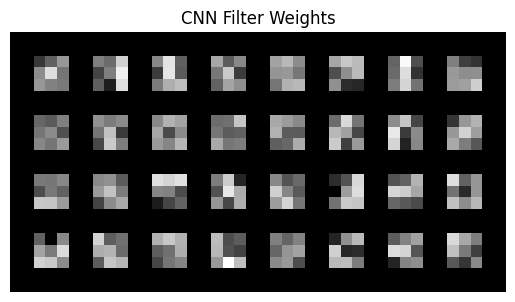

In [ ]:
import torchvision
import matplotlib.pyplot as plt

# Create a grid of images
# nrow defines the number of filters per row
weights = weights.cpu()
grid_image = torchvision.utils.make_grid(weights, nrow=8, normalize=True)

# Matplotlib expects H x W x C, so we transpose
plt.imshow(grid_image.numpy().transpose((1, 2, 0)))
plt.axis('off')
plt.title("CNN Filter Weights")
plt.show()



## Part B: Colored-MNIST (C-MNIST)

# Task 2: Transfer Learning and **Interpretability**

## Part A: Fine-tuning ResNet-18

In [62]:
BATCH_SIZE = 64
EPOCHS = 40

### Setting Up Data

In [52]:
# setting up transform for data normalization
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# loading dataset
total_train_dataset = torchvision.datasets.STL10(root="data", split='train', transform=transform, download=True)
test_dataset = torchvision.datasets.STL10(root="data", split='test', transform=transform, download=True)

# splitting training data into train and validation
train_size = int(0.8 * len(total_train_dataset))
val_size = len(total_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    total_train_dataset,
    [train_size, val_size]
)

# setting up loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)} Test: {len(test_dataset)}")

Train: 4000, Val: 1000 Test: 8000


### Loading model

In [68]:
#load model
pre_trained_resnet = models.resnet18(pretrained=True)


In [27]:
pre_trained_resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [69]:
# freeze layers
for param in pre_trained_resnet.parameters():
    param.requires_grad = False

In [70]:
# Modify the last layer of the model
num_classes = 10
pre_trained_resnet.fc = torch.nn.Linear(pre_trained_resnet.fc.in_features, num_classes)
pre_trained_resnet = pre_trained_resnet.to(device)

In [59]:
# pre_trained_resnet.load_state_dict(torch.load("/content/resnet_weights.pth"))

<All keys matched successfully>

### Hyperparams

In [71]:
# hyperparameters
l_r = 0.001
optimizer = optim.Adam(filter(lambda p: p.requires_grad, pre_trained_resnet.parameters()), lr=l_r, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

cudnn.benchmark = True #to treat it as benchmark testing for speeding up process

### Training Model

In [72]:
train_loss_curve = []
val_loss_curve = []
train_model(pre_trained_resnet, criterion, optimizer, train_loss_curve, val_loss_curve)

Epoch 1
Train Loss: 69.13180354284862, Val Loss: 0.5085561759769917

Epoch 2
Train Loss: 24.98816164713057, Val Loss: 0.3291888292878866

Epoch 3
Train Loss: 18.1458714651683, Val Loss: 0.28022842202335596

Epoch 4
Train Loss: 15.214413991050115, Val Loss: 0.2454462954774499

Epoch 5
Train Loss: 13.387620176587786, Val Loss: 0.22526337020099163

Epoch 6
Train Loss: 11.84921748297555, Val Loss: 0.21569714043289423

Epoch 7
Train Loss: 10.877335453790332, Val Loss: 0.21181365475058556

Epoch 8
Train Loss: 10.170495827992758, Val Loss: 0.21039527980610728

Epoch 9
Train Loss: 9.513728119078136, Val Loss: 0.19941156869754195

Epoch 10
Train Loss: 8.66163406674824, Val Loss: 0.19374865805730224

Epoch 11
Train Loss: 8.075954176130749, Val Loss: 0.19838164513930678

Epoch 12
Train Loss: 7.9367809939006015, Val Loss: 0.1963804461993277

Epoch 13
Train Loss: 7.354025500161307, Val Loss: 0.19512096978724003

Epoch 14
Train Loss: 6.826404760754298, Val Loss: 0.19508084934204817

Epoch 15
Train L

In [73]:
torch.save(pre_trained_resnet.state_dict(), 'resnet_weights.pth')

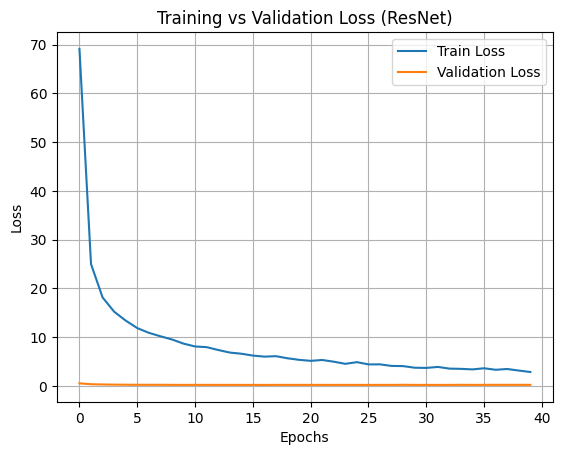

In [74]:
plt.plot(train_loss_curve, label='Train Loss')
plt.plot(val_loss_curve, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (ResNet)')
plt.legend()
plt.grid()

plt.show()

### Testing Model

In [82]:
def evaluate_model_with_track(model):
    model.eval()

    correct_pred = 0
    total = 0

    correct_images = []
    correct_labels = []
    correct_preds = []

    wrong_images = []
    wrong_labels = []
    wrong_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct_pred += (preds == labels).sum().item()

            # 🔹 Loop through batch
            for i in range(len(labels)):

                # Correct predictions
                if preds[i] == labels[i] and len(correct_images) < 5:
                    correct_images.append(images[i].cpu())
                    correct_labels.append(labels[i].cpu())
                    correct_preds.append(preds[i].cpu())

                # wrong predictions
                elif preds[i] != labels[i] and len(wrong_images) < 5:
                    wrong_images.append(images[i].cpu())
                    wrong_labels.append(labels[i].cpu())
                    wrong_preds.append(preds[i].cpu())

                # Stop early if we have enough
                if len(correct_images) >= 5 and len(wrong_images) >= 5:
                    break

            if len(correct_images) >= 5 and len(wrong_images) >= 5:
                break

    acc = 100 * correct_pred / total
    print(f"Accuracy: {acc:.2f}%")

    return (correct_images, correct_labels, correct_preds,
            wrong_images, wrong_labels, wrong_preds)

In [83]:
correct_imgs, correct_lbls, correct_preds, \
wrong_imgs, wrong_lbls, wrong_preds = evaluate_model_with_track(pre_trained_resnet)

Accuracy: 92.97%


###  Analytical Question 2.1:

#### Why is it computationally and functionally beneficial to reeze the early layers of a pre-trained network when fine-tuning on a relatively small dataset like STL-10? What type of features are stored in those early layers compared to the later layers?


It is computationally beneficial to freese early layers in a pretrained network as these layers capture information about features of images like edges, contours and shadows ets which are helpful in other image datasets as well. When we dont have enough dataset or our dataset size is small then we dont have sufficient data to properly train our models. In these cases, we can make use of already learned common features from pretrained models and just train the final FC layer to work for our particular dataset. This saves time, compute power, and the need for large datasets.
THe early layers extract features like colors, edges, contours and shadows etc whereas later layers extract more refined features depending on the dataset so we can use this to our advantage and utilize the pretrained earlier layers and only train some later layers to save compute.

## Part B: Visualizing Decisions with GradCAM